# Chapter 3 — Statistical Experiments and Significance Testing

Chapter ini membahas desain eksperimen statistik dan statistical significance testing.

Tujuan utama desain eksperimen adalah merancang suatu eksperimen untuk menguji sebuah hipotesis. Dalam data science, eksperimen seperti A/B testing sering digunakan untuk membandingkan dua atau lebih perlakuan, misalnya desain halaman web, harga produk, judul artikel, atau iklan.

Chapter ini juga membahas hypothesis tests, resampling, permutation tests, p-values, t-tests, multiple testing, degrees of freedom, ANOVA, chi-square tests, multi-arm bandit algorithms, serta power dan sample size.

## A/B Testing

A/B testing adalah eksperimen yang membandingkan dua kelompok untuk mengetahui perbedaan akibat dua treatment yang berbeda.

Contohnya:
- Membandingkan dua desain halaman web.
- Membandingkan dua harga produk.
- Membandingkan dua judul artikel.
- Membandingkan dua iklan.
- Membandingkan dua metode atau perlakuan.

Dalam A/B testing, subjek eksperimen dibagi ke dalam kelompok treatment dan control.

### Istilah penting

**Treatment**  
Perlakuan yang diberikan kepada subjek, seperti harga, desain halaman web, obat, atau headline.

**Treatment Group**  
Kelompok subjek yang mendapatkan treatment tertentu.

**Control Group**  
Kelompok yang mendapatkan kondisi standar atau tidak mendapatkan treatment.

**Randomization**  
Proses membagi subjek ke dalam treatment secara acak.

**Subjects**  
Objek yang menerima treatment, misalnya pengunjung website atau pasien.

**Test Statistic**  
Metrik yang digunakan untuk mengukur efek atau perbedaan treatment.

### Randomization

Randomization merupakan proses menempatkan subjects ke dalam treatment secara acak.

Randomization penting karena membantu memastikan bahwa perbedaan antara treatment group dan control group terutama berasal dari:

1. Efek treatment yang berbeda.
2. Random chance dalam pembagian subjects.

Dengan randomization, karakteristik subjects diharapkan tidak terkonsentrasi secara sistematis hanya pada salah satu kelompok.

## Why Have a Control Group?

Control group diperlukan agar hasil eksperimen dapat dibandingkan dengan kondisi yang tidak mendapatkan treatment atau mendapatkan treatment standar.

Tanpa control group, sulit memastikan bahwa perubahan yang diamati benar-benar disebabkan oleh treatment.

Perbedaan hasil dapat dipengaruhi oleh faktor lain yang berubah selama eksperimen.

Dalam A/B testing, control group mengalami kondisi yang sama dengan treatment group, kecuali treatment yang sedang diuji.

## Why Just A/B? Why Not C, D, ...?

Eksperimen tidak selalu hanya memiliki dua treatment.

Kita dapat memiliki beberapa treatment sekaligus, misalnya:

- Treatment A
- Treatment B
- Treatment C
- Treatment D

A/B testing digunakan ketika kita ingin membandingkan dua pilihan.

Namun, ketika jumlah treatment semakin banyak, permasalahan eksperimen menjadi lebih kompleks.

Dalam data science, sering kali tujuan eksperimen bukan hanya menentukan apakah A berbeda dengan B, tetapi menentukan pilihan terbaik dari beberapa alternatif.

Untuk situasi dengan banyak pilihan, chapter ini kemudian memperkenalkan konsep Multi-Arm Bandit Algorithm.

### Contoh Data A/B Testing

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset A/B Testing dari repository resmi buku
session_times = pd.read_csv(
    'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/web_page_data.csv'
)

session_times.head()

,Page,Time
0,Page A,0.21
1,Page B,2.53
2,Page A,0.35
3,Page B,0.71
4,Page A,0.67


### Cek Data

In [9]:
print(session_times.head())

print()
print("Nilai Page:")
print(session_times['Page'].unique())

print()
print("Jumlah masing-masing Page:")
print(session_times['Page'].value_counts())

     Page  Time
0  Page A  0.21
1  Page B  2.53
2  Page A  0.35
3  Page B  0.71
4  Page A  0.67

Nilai Page:
['Page A' 'Page B']

Jumlah masing-masing Page:
Page
Page A    21
Page B    15
Name: count, dtype: int64


### Visualisasi A/B Testing

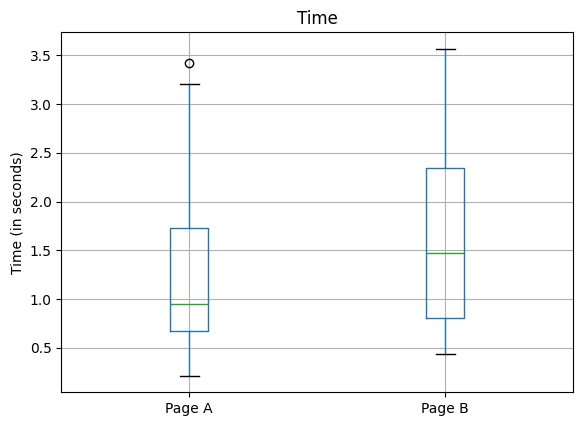

In [10]:
ax = session_times.boxplot(by='Page', column='Time')

ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')

plt.suptitle('')
plt.show()

### Menghitung Mean Page A dan Page B

In [11]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()

print("Mean Page A:", mean_a)
print("Mean Page B:", mean_b)
print("Selisih Mean (Page B - Page A):", mean_b - mean_a)

Mean Page A: 1.2633333333333332
Mean Page B: 1.62
Selisih Mean (Page B - Page A): 0.3566666666666669


### Hasil Perbandingan Page A dan Page B

Berdasarkan perhitungan rata-rata, Page A memiliki nilai rata-rata Time sebesar 1,2633, sedangkan Page B memiliki nilai rata-rata sebesar 1,6200.

Selisih rata-rata antara Page B dan Page A adalah 0,3567. Hasil ini menunjukkan adanya perbedaan rata-rata waktu sesi antara kedua halaman.

Namun, perbedaan rata-rata saja belum cukup untuk menentukan apakah perbedaan tersebut merupakan hasil dari perlakuan yang diberikan atau hanya terjadi karena variasi acak dalam sampel. Oleh karena itu, diperlukan pengujian statistik menggunakan permutation test.

## Hypothesis Tests

Hypothesis test adalah analisis lebih lanjut terhadap A/B test atau eksperimen yang telah dilakukan secara acak.

Tujuan hypothesis test adalah menilai apakah perbedaan yang diamati antara dua kelompok masih dapat dijelaskan oleh random chance atau memberikan bukti bahwa terdapat perbedaan yang sebenarnya.

Dalam eksperimen A/B, perbedaan antara kelompok A dan B dapat berasal dari:

1. Random chance dalam pembagian subjek ke dalam kelompok.
2. Perbedaan yang benar-benar terjadi antara A dan B.

Hypothesis test digunakan untuk menilai apakah random chance merupakan penjelasan yang masuk akal terhadap perbedaan yang diamati.

### The Null Hypothesis

Null hypothesis adalah asumsi dasar bahwa tidak terjadi sesuatu yang khusus dan perbedaan yang diamati antara kelompok terjadi karena random chance.

Dalam A/B testing, null hypothesis biasanya menganggap bahwa treatment A dan treatment B sebenarnya setara.

Contoh:

**Null hypothesis:**
Tidak terdapat perbedaan antara rata-rata kelompok A dan kelompok B.

Dengan demikian, perbedaan yang terlihat pada data dianggap masih dapat terjadi karena random chance.

Hypothesis test kemudian menggunakan null hypothesis sebagai dasar untuk membentuk sebuah **null model**, yaitu model probabilitas yang menggambarkan kondisi ketika tidak terdapat perbedaan nyata antara kelompok.

Selanjutnya, hasil yang diamati dibandingkan dengan hasil yang mungkin terjadi berdasarkan null model.

### Alternative Hypothesis

Alternative hypothesis merupakan hipotesis yang berlawanan dengan null hypothesis.

Null hypothesis dan alternative hypothesis harus bersama-sama mencakup seluruh kemungkinan yang sedang diuji.

Contoh:

### Contoh 1 — Dua arah

Null hypothesis:
Tidak terdapat perbedaan antara rata-rata A dan B.

Alternative hypothesis:
A berbeda dari B, baik lebih besar maupun lebih kecil.

### Contoh 2 — Satu arah

Null hypothesis:
A ≤ B

Alternative hypothesis:
A > B

### Contoh 3 — Berdasarkan persentase

Null hypothesis:
B tidak lebih besar X% daripada A.

Alternative hypothesis:
B lebih besar X% daripada A.

Bentuk alternative hypothesis akan menentukan bagaimana hypothesis test dilakukan.

### One-Way Versus Two-Way Hypothesis Tests

### One-Way / One-Tail Test

One-way atau one-tail hypothesis test digunakan ketika alternative hypothesis memiliki arah tertentu.

Contohnya:

**Alternative hypothesis:**
B lebih baik daripada A.

Dalam kondisi ini, hasil ekstrem yang diperhitungkan untuk p-value hanya berasal dari satu arah.

Misalnya:

**B > A**

Maka perhatian diberikan pada hasil yang menunjukkan B jauh lebih besar daripada A.

---

### Two-Way / Two-Tail Test

Two-way atau two-tail hypothesis test digunakan ketika kita ingin mengetahui apakah terdapat perbedaan dalam kedua arah.

Contohnya:

**Alternative hypothesis:**
A berbeda dari B.

Bisa berarti:

- A > B
- A < B

Karena kedua arah diperhitungkan, hasil ekstrem dari kedua sisi distribusi dapat berkontribusi terhadap p-value.

---

### One-Tail vs Two-Tail dalam A/B Testing

Dalam A/B testing, one-tail test dapat digunakan ketika terdapat default option dan hanya ingin mengetahui apakah pilihan baru terbukti lebih baik.

Namun, software statistik seperti R dan scipy di Python umumnya memberikan hasil two-tail test sebagai default.

Buku juga menjelaskan bahwa pilihan one-tail atau two-tail dapat menjadi topik yang membingungkan dan tidak terlalu penting untuk data science ketika presisi perhitungan p-value bukan fokus utama.

### Perbandingan One-Tail dan Two-Tail

| Jenis | Alternative Hypothesis | Arah yang diperhatikan |
|---|---|---|
| One-Tail | B > A | Satu arah |
| One-Tail | B < A | Satu arah |
| Two-Tail | B ≠ A | Dua arah |

**One-Tail:**
Menguji apakah perbedaan terjadi dalam arah tertentu.

**Two-Tail:**
Menguji apakah terdapat perbedaan, tanpa menentukan arah sebelumnya.

### Key Ideas — Hypothesis Tests

- Null hypothesis merupakan asumsi bahwa tidak terjadi sesuatu yang khusus dan perbedaan yang diamati dapat disebabkan oleh random chance.
- Hypothesis test menggunakan null hypothesis sebagai dasar untuk membentuk null model.
- Null model digunakan untuk menilai apakah hasil yang diamati masih merupakan hasil yang masuk akal jika null hypothesis benar.
- Alternative hypothesis merupakan hipotesis yang berlawanan dengan null hypothesis.
- One-tail hypothesis test digunakan ketika alternative hypothesis memiliki arah tertentu.
- Two-tail hypothesis test digunakan ketika alternative hypothesis memungkinkan perbedaan dalam dua arah.

## Resampling — Permutation Test

Permutation test digunakan untuk mengetahui apakah perbedaan antara dua kelompok dapat terjadi hanya karena variasi acak.

Pada contoh A/B Testing, kita memiliki dua kelompok:
- Page A: 21 sesi
- Page B: 15 sesi

Perbedaan rata-rata waktu sesi yang diamati adalah perbedaan antara mean Page B dan mean Page A.

Dalam permutation test, seluruh nilai waktu sesi digabungkan, kemudian secara acak dibagi kembali menjadi dua kelompok dengan ukuran yang sama seperti data asli. Proses ini diulang sebanyak 1.000 kali.

Jika perbedaan rata-rata yang diamati sering muncul dalam hasil pengacakan, maka perbedaan tersebut masih berada dalam rentang variasi acak.

### Membuat fungsi Permutation Test

In [19]:
import random

def perm_fun(x, nA, nB):
    n = nA + nB

    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B

    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

### Menentukan jumlah Page A dan Page B

In [13]:
nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]

print("Jumlah Page A:", nA)
print("Jumlah Page B:", nB)

Jumlah Page A: 21
Jumlah Page B: 15


### Coba satu kali Permutation Test

In [22]:
perm_fun(session_times.Time, nA, nB)

np.float64(0.2846666666666666)

### 1.000 permutation

In [24]:
random.seed(1)

perm_diffs = [
    perm_fun(session_times.Time, nA, nB)
    for _ in range(1000)
]

print("Jumlah permutation:", len(perm_diffs))

Jumlah permutation: 1000


### Visualisasi Permutation Distribution

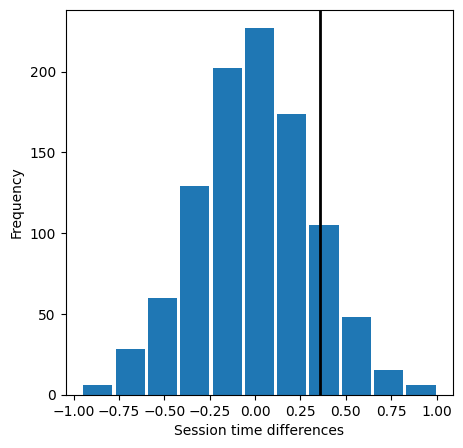

In [28]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.hist(perm_diffs, bins=11, rwidth=0.9)

ax.axvline(
    x=mean_b - mean_a,
    color='black',
    lw=2
)

ax.set_xlabel('Session time differences')
ax.set_ylabel('Frequency')

plt.show()

### Hitung permutation p-value

In [27]:
import numpy as np

p_value_permutation = np.mean(
    np.array(perm_diffs) > (mean_b - mean_a)
)

print("Permutation p-value:", p_value_permutation)

Permutation p-value: 0.121


### Interpretasi Permutation Test

Permutation test dilakukan dengan mengacak pembagian data Page A dan Page B sebanyak 1.000 kali. Setiap pengacakan menghasilkan selisih rata-rata antara kelompok B dan kelompok A.

Distribusi hasil permutation kemudian dibandingkan dengan selisih rata-rata yang diperoleh dari data asli, yaitu sekitar 0,3567.

Permutation p-value berada di sekitar 0,12. Hal ini menunjukkan bahwa perbedaan rata-rata seperti yang diamati masih dapat muncul dalam proses pengacakan dengan frekuensi yang cukup besar.

Dengan demikian, hasil permutation test pada contoh ini belum memberikan bukti statistik yang kuat bahwa perbedaan waktu sesi antara Page A dan Page B berbeda dari variasi acak.

# Statistical Significance and p-Values

Statistical significance digunakan untuk mengukur apakah hasil suatu eksperimen lebih ekstrem dibandingkan hasil yang mungkin terjadi karena variasi acak.

Jika hasil yang diamati berada di luar rentang variasi yang secara wajar dapat dihasilkan oleh chance variation, hasil tersebut disebut statistically significant.

Dalam pengujian statistik, p-value digunakan untuk mengukur seberapa ekstrem hasil yang diamati jika kita mengasumsikan bahwa tidak ada efek atau perbedaan yang sebenarnya.

Pada contoh A/B Testing, permutation test digunakan untuk membentuk distribusi hasil yang mungkin terjadi jika perbedaan antara Page A dan Page B hanya disebabkan oleh variasi acak.

## p-Value

p-value adalah probabilitas untuk mendapatkan hasil yang sama ekstrem atau lebih ekstrem dibandingkan hasil yang diamati, dengan asumsi bahwa model chance yang mewakili null hypothesis benar.

Dengan kata lain, p-value membantu kita menilai seberapa tidak biasa hasil yang diamati jika tidak terdapat efek yang sebenarnya.

Semakin kecil p-value, semakin tidak biasa hasil tersebut jika null hypothesis benar.

## Alpha

Alpha adalah batas probabilitas yang ditentukan sebelumnya untuk menentukan seberapa ekstrem suatu hasil harus terjadi agar dianggap statistically significant.

Nilai alpha yang umum digunakan adalah:

- α = 0.05
- α = 0.01

Jika p-value berada di bawah alpha yang telah ditentukan, hasil dianggap statistically significant menurut kriteria tersebut.

## Type 1 and Type 2 Errors

Dalam pengujian hipotesis terdapat dua jenis kesalahan utama.

### Type 1 Error

Type 1 error terjadi ketika kita menyimpulkan bahwa suatu efek benar-benar ada, padahal efek tersebut sebenarnya hanya terjadi karena chance.

Contohnya adalah menyimpulkan bahwa Page B memiliki perbedaan yang nyata ketika sebenarnya perbedaan tersebut hanya merupakan variasi acak.

### Type 2 Error

Type 2 error terjadi ketika kita menyimpulkan bahwa hasil yang diamati disebabkan oleh chance, padahal sebenarnya terdapat efek yang nyata.

Dengan demikian:

- Type 1 Error → menganggap ada efek padahal tidak ada.
- Type 2 Error → menganggap tidak ada efek padahal sebenarnya ada.

## Data Science and p-Values

Dalam data science, p-value tidak seharusnya digunakan sebagai satu-satunya ukuran untuk menentukan apakah suatu hasil penting atau tidak.

Statistical significance dan practical significance merupakan dua hal yang berbeda.

Suatu perbedaan dapat secara statistik signifikan tetapi memiliki dampak praktis yang kecil. Sebaliknya, suatu perbedaan yang memiliki dampak praktis dapat saja tidak menghasilkan statistical significance jika data yang tersedia tidak cukup untuk mendeteksinya.

Oleh karena itu, p-value perlu dipertimbangkan bersama konteks eksperimen, ukuran efek, ukuran sampel, dan konsekuensi praktis dari hasil yang diperoleh.

# t-Tests

t-test merupakan metode statistik yang dapat digunakan untuk membandingkan dua kelompok data numerik.

Pada contoh A/B Testing, kita ingin mengetahui apakah terdapat perbedaan antara rata-rata waktu sesi Page A dan Page B.

t-test menggunakan t-distribution untuk menilai seberapa ekstrem perbedaan yang diamati.

Untuk contoh ini digunakan two-sample t-test dengan asumsi varians kedua kelompok tidak harus sama (Welch's t-test).

## Jalankan t-Test

In [29]:
from scipy import stats

res = stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time,
    session_times[session_times.Page == 'Page B'].Time,
    equal_var=False
)

print(f'p-value for single sided test: {res.pvalue / 2:.4f}')

p-value for single sided test: 0.1408


### Interpretasi t-Test

Hasil t-test menghasilkan p-value one-sided sebesar 0.1408.

Nilai tersebut lebih besar daripada alpha 0.05. Dengan demikian, hasil pengujian tidak memenuhi threshold statistical significance pada tingkat alpha 0.05.

Hasil t-test juga memiliki nilai yang cukup dekat dengan hasil permutation test sebelumnya. Hal ini menunjukkan bahwa kedua pendekatan memberikan gambaran yang serupa mengenai variasi antara Page A dan Page B pada contoh ini.

# Multiple Testing

Multiple testing terjadi ketika kita melakukan banyak pengujian statistik terhadap data yang sama.

Masalah utama multiple testing adalah semakin banyak pengujian yang dilakukan, semakin besar kemungkinan kita mendapatkan hasil yang terlihat statistically significant hanya karena chance.

Sebagai contoh, jika terdapat 20 predictor variables yang sebenarnya dihasilkan secara acak dan masing-masing diuji dengan alpha = 0.05, kemungkinan setidaknya satu predictor akan terlihat significant secara kebetulan menjadi cukup besar.

Hal ini disebut sebagai alpha inflation.

## Mengapa Multiple Testing Menjadi Masalah?

Jika hanya satu pengujian dilakukan dengan alpha = 0.05, peluang melakukan Type 1 error berada pada tingkat 5%.

Namun, ketika banyak pengujian dilakukan, peluang untuk mendapatkan setidaknya satu hasil significant secara kebetulan meningkat.

Misalnya terdapat 20 pengujian independen dengan alpha = 0.05:

P(semua tidak significant) = 0.95^20 ≈ 0.36

Sehingga:

P(setidaknya satu significant secara kebetulan)
= 1 - 0.36
≈ 0.64

Artinya, meskipun seluruh predictor sebenarnya tidak memiliki hubungan dengan outcome, melakukan banyak pengujian dapat menghasilkan setidaknya satu hasil yang terlihat significant karena chance.

## Key Terms for Multiple Testing

### Type 1 Error

Kesalahan ketika menyimpulkan bahwa suatu efek statistically significant, padahal sebenarnya efek tersebut tidak ada.

### False Discovery Rate

Pada multiple testing, false discovery rate berkaitan dengan tingkat Type 1 error yang terjadi di antara berbagai hasil yang dianggap sebagai discovery.

### Alpha Inflation

Fenomena ketika probabilitas melakukan Type 1 error meningkat karena semakin banyak pengujian dilakukan.

### Adjustment of p-Values

Proses melakukan penyesuaian terhadap p-value karena terdapat multiple tests yang dilakukan pada data yang sama.

### Overfitting

Fitting the noise, yaitu ketika model atau analisis terlalu menyesuaikan diri dengan variasi acak pada data.

## Multiple Comparisons

Ketika terdapat beberapa kelompok, kita dapat melakukan banyak pairwise comparisons.

Misalnya terdapat tiga kelompok:

- A dibandingkan dengan B
- B dibandingkan dengan C
- A dibandingkan dengan C

Setiap perbandingan merupakan pengujian statistik tersendiri.

Semakin banyak perbandingan dilakukan, semakin besar kemungkinan salah satu hasil terlihat statistically significant hanya karena chance.

Karena itu, multiple comparisons perlu diperhatikan ketika melakukan banyak statistical tests terhadap data yang sama.

## Adjustment untuk Multiple Testing

Untuk situasi yang melibatkan multiple statistical comparisons, terdapat prosedur untuk melakukan adjustment terhadap hasil pengujian.

Beberapa pendekatan yang dibahas dalam referensi yang disebut buku antara lain:

- Dunnett's test
- Bonferroni adjustment
- Resampling-based multiple testing

Tujuan adjustment adalah memperhitungkan fakta bahwa beberapa statistical tests telah dilakukan terhadap data yang sama.

## Multiple Testing dalam Data Science

Dalam data science, masalah multiple testing dapat muncul ketika:

- melakukan banyak perbandingan,
- menggunakan banyak variables,
- mencoba banyak model,
- atau melakukan banyak eksplorasi terhadap dataset.

Semakin banyak analisis dan model yang dicoba, semakin besar peran chance dalam menghasilkan pola yang terlihat significant.

Untuk predictive modeling, penggunaan cross-validation dan holdout sample dapat membantu mengurangi risiko mendapatkan model yang terlihat memiliki performa baik hanya karena random chance.

Untuk situasi tanpa labeled holdout set, kita perlu menyadari bahwa semakin banyak data dimanipulasi dan pertanyaan yang diajukan, semakin besar kemungkinan menemukan hasil yang muncul karena chance.

Resampling dan simulation dapat digunakan untuk menyediakan benchmark terhadap random chance.

## Key Ideas — Multiple Testing

- Multiplicity dalam research study atau data mining project meningkatkan risiko menyimpulkan bahwa sesuatu significant hanya karena chance.
- Multiple comparisons, banyak variables, dan banyak models merupakan contoh sumber multiplicity.
- Multiple statistical comparisons dapat memerlukan statistical adjustment procedures.
- Dalam predictive modeling, holdout sample dan cross-validation dapat membantu mengurangi risiko hasil yang misleading.
- Ketika tidak tersedia labeled holdout set, resampling dan simulation dapat digunakan sebagai benchmark terhadap random chance.

## Degrees of Freedom

Degrees of Freedom (derajat kebebasan) adalah jumlah nilai dalam suatu perhitungan statistik yang masih dapat berubah secara bebas setelah terdapat batasan tertentu.

Secara sederhana, degrees of freedom menunjukkan berapa banyak informasi yang benar-benar bebas digunakan untuk memperkirakan suatu parameter statistik.

### Contoh sederhana

Misalkan terdapat 10 nilai dan kita sudah mengetahui nilai rata-ratanya.

Karena rata-rata sudah ditentukan, jika 9 nilai pertama sudah diketahui, maka nilai ke-10 tidak lagi bebas ditentukan. Nilai tersebut harus mengikuti agar rata-ratanya tetap sama.

Oleh karena itu:

**Degrees of Freedom = n - 1**

dengan:
- `n` = jumlah observasi
- `1` = satu batasan karena rata-rata sampel telah ditentukan

Untuk 10 observasi:

**df = 10 - 1 = 9**

### Degrees of Freedom pada Varians

Degrees of freedom juga menjelaskan mengapa varians sampel menggunakan `n - 1` sebagai penyebut:

**Sample Variance = Σ(xᵢ - x̄)² / (n - 1)**

Penggunaan `n - 1` membantu mengoreksi kecenderungan varians sampel untuk terlalu rendah ketika digunakan untuk memperkirakan varians populasi.

### Degrees of Freedom dalam Statistical Tests

Degrees of freedom digunakan dalam berbagai metode statistik, termasuk:

- t-test
- ANOVA
- F-test
- regresi

Nilai degrees of freedom memengaruhi distribusi referensi yang digunakan dalam pengujian statistik.

Dalam data science, degrees of freedom tidak selalu menjadi fokus utama. Namun, pemahaman mengenai degrees of freedom tetap diperlukan agar dapat memahami dan menginterpretasikan hasil statistical tests dengan benar.

### Key Terms

- **Degrees of Freedom (df):** jumlah nilai yang dapat bervariasi secara bebas setelah memperhitungkan batasan statistik.
- **Sample Size (n):** jumlah observasi dalam sampel.
- **n - 1:** degrees of freedom yang umum digunakan ketika memperkirakan varians dari satu sampel.

In [30]:
# CODE TAMBAHAN / SUPPORT
# Demonstrasi Degrees of Freedom

data = [10, 20, 30, 40, 50]

n = len(data)
df = n - 1

print("Jumlah observasi (n):", n)
print("Degrees of Freedom (df):", df)

Jumlah observasi (n): 5
Degrees of Freedom (df): 4


### Key Ideas — Degrees of Freedom

1. Degrees of Freedom menunjukkan jumlah nilai yang dapat berubah secara bebas setelah terdapat batasan tertentu.
2. Untuk satu sampel ketika rata-rata sampel digunakan sebagai estimasi, degrees of freedom umumnya adalah `n - 1`.
3. Penggunaan `n - 1` pada varians sampel membantu mengoreksi kecenderungan estimasi varians sampel yang terlalu rendah.
4. Degrees of freedom digunakan dalam berbagai statistical tests seperti t-test dan ANOVA.
5. Dalam data science, degrees of freedom terutama penting untuk memahami dan menginterpretasikan statistical tests.

# ANOVA (Analysis of Variance)

ANOVA (Analysis of Variance) adalah prosedur statistik untuk menganalisis hasil eksperimen yang melibatkan beberapa kelompok.

ANOVA merupakan pengembangan dari pendekatan A/B testing. Jika A/B testing membandingkan dua kelompok, ANOVA digunakan ketika terdapat beberapa kelompok yang ingin dibandingkan secara keseluruhan.

Tujuan utama ANOVA adalah mengetahui apakah variasi atau perbedaan antar-group mean masih berada dalam rentang yang dapat dijelaskan oleh random chance.

Dalam contoh web testing pada buku, terdapat empat halaman web:

- Page 1
- Page 2
- Page 3
- Page 4

Masing-masing halaman diberikan secara acak kepada pengunjung dan waktu yang dihabiskan pengunjung pada halaman tersebut digunakan sebagai ukuran stickiness.

Dengan empat kelompok, terdapat banyak kemungkinan perbandingan berpasangan. Daripada melakukan banyak pengujian secara terpisah, ANOVA memberikan satu pengujian keseluruhan terhadap perbedaan antar-kelompok.

## Data ANOVA

In [31]:
import pandas as pd

four_sessions = pd.read_csv(
    'https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/four_sessions.csv'
)

four_sessions

,Page,Time
0,Page 1,164
1,Page 2,178
2,Page 3,175
3,Page 4,155
4,Page 1,172
5,Page 2,191
6,Page 3,193
7,Page 4,166
8,Page 1,177
9,Page 2,182


## Group Means

Sebelum melakukan ANOVA, kita dapat melihat rata-rata setiap kelompok.

Pada data web page stickiness, terdapat empat rata-rata kelompok:

- Page 1
- Page 2
- Page 3
- Page 4

Selain rata-rata setiap kelompok, terdapat pula **grand average**, yaitu rata-rata seluruh observasi.

In [33]:
group_means = four_sessions.groupby('Page')['Time'].mean()

print("Rata-rata setiap Page:")
print(group_means)

print("\nGrand average:")
print(four_sessions['Time'].mean())

Rata-rata setiap Page:
Page
Page 1    172.8
Page 2    182.6
Page 3    175.6
Page 4    164.6
Name: Time, dtype: float64

Grand average:
173.9


## Mengapa Menggunakan ANOVA?

Jika terdapat empat kelompok, terdapat enam kemungkinan perbandingan berpasangan:

1. Page 1 dibandingkan dengan Page 2
2. Page 1 dibandingkan dengan Page 3
3. Page 1 dibandingkan dengan Page 4
4. Page 2 dibandingkan dengan Page 3
5. Page 2 dibandingkan dengan Page 4
6. Page 3 dibandingkan dengan Page 4

Semakin banyak perbandingan yang dilakukan, semakin besar peluang untuk mendapatkan hasil yang terlihat berbeda hanya karena random chance.

ANOVA memberikan satu pengujian keseluruhan untuk mengetahui apakah perbedaan antar-group means secara keseluruhan lebih besar daripada yang dapat diharapkan dari random variation.

## ANOVA dengan Permutation Test

Untuk menguji apakah perbedaan antar-group means dapat terjadi karena random chance, data dari seluruh kelompok dapat digabungkan dan kemudian diacak.

Prosedurnya:

1. Gabungkan seluruh data menjadi satu kelompok.
2. Acak data tersebut.
3. Bagi kembali menjadi empat kelompok dengan masing-masing lima nilai.
4. Hitung rata-rata dari masing-masing kelompok.
5. Hitung variance dari keempat group means.
6. Ulangi proses tersebut berkali-kali.
7. Bandingkan variance hasil resampling dengan variance yang diamati pada data asli.

Proporsi hasil resampling yang memiliki variance lebih besar daripada variance yang diamati digunakan sebagai p-value.

In [34]:
import numpy as np

observed_variance = four_sessions.groupby('Page').mean().var()[0]

print('Observed means:',
      four_sessions.groupby('Page').mean().values.ravel())

print('Variance:', observed_variance)


def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var()[0]


perm_variance = [
    perm_test(four_sessions)
    for _ in range(3000)
]

print(
    'Pr(Prob)',
    np.mean([
        var > observed_variance
        for var in perm_variance
    ])
)

/tmp/ipykernel_2239/1499579890.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  observed_variance = four_sessions.groupby('Page').mean().var()[0]
/tmp/ipykernel_2239/1499579890.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return df.groupby('Page').mean().var()[0]
/tmp/ipykernel_2239/1499579890.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return df.groupby('Page').mean().var()[0]
/tmp/ipykernel_2239/1499579890.py:1

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655


/tmp/ipykernel_2239/1499579890.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return df.groupby('Page').mean().var()[0]
/tmp/ipykernel_2239/1499579890.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return df.groupby('Page').mean().var()[0]
/tmp/ipykernel_2239/1499579890.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return df.groupby('Page').mean().var()[0]
/tmp/ipykernel_2239/1499579890.py:14: FutureWarning: Serie

Pr(Prob) 0.087


/tmp/ipykernel_2239/1499579890.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return df.groupby('Page').mean().var()[0]
/tmp/ipykernel_2239/1499579890.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return df.groupby('Page').mean().var()[0]
/tmp/ipykernel_2239/1499579890.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return df.groupby('Page').mean().var()[0]
/tmp/ipykernel_2239/1499579890.py:14: FutureWarning: Serie

## F-Statistic

Selain permutation test, ANOVA juga dapat menggunakan F-statistic.

F-statistic didasarkan pada rasio antara:

**Variability among group means**

dan

**Variability due to residual error**

Secara sederhana:

F = MS(treatment) / MS(error)

dengan:

- MS(treatment) = mean square yang berkaitan dengan perbedaan antar-group means
- MS(error) = mean square yang berkaitan dengan residual/error

Semakin besar rasio tersebut, semakin besar perbedaan antar-group means dibandingkan dengan variasi residual.

Nilai F kemudian dapat dibandingkan dengan F-distribution untuk memperoleh p-value.

## ANOVA Table dengan Python

In [35]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols(
    'Time ~ Page',
    data=four_sessions
).fit()

aov_table = sm.stats.anova_lm(model)

aov_table

,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


## Memahami ANOVA Table

Output ANOVA memiliki beberapa komponen penting:

### Df — Degrees of Freedom

Df adalah degrees of freedom yang terkait dengan masing-masing komponen variasi.

Untuk treatment Page terdapat 3 degrees of freedom karena terdapat empat group means.

### Sum Sq — Sum of Squares

Sum of Squares mengukur jumlah squared deviations dari suatu nilai rata-rata tertentu.

### Mean Sq — Mean Squares

Mean Square diperoleh dengan membagi Sum of Squares dengan Degrees of Freedom.

**Mean Sq = Sum Sq / Df**

### F value

F value merupakan F-statistic:

**F = MS(treatment) / MS(error)**

### Pr(>F)

Pr(>F) merupakan p-value yang berkaitan dengan F-statistic.

Nilai ini digunakan untuk menilai apakah perbedaan antar-group means masih konsisten dengan random chance.

## Decomposition of Variance

Nilai observasi dalam data dapat dipandang sebagai gabungan dari beberapa komponen:

**Observed value = Grand average + Treatment effect + Residual error**

Pada contoh web page stickiness:

1. Mulai dari grand average = 173.75
2. Tambahkan treatment effect
3. Tambahkan residual error

Contoh nilai pertama:

Observed value = 164

Grand average = 173.75

Treatment effect = 172 - 173.75 = -1.75

Residual = 164 - 172 = -8

Sehingga:

173.75 + (-1.75) + (-8) = 164

## Two-Way ANOVA

ANOVA pada contoh Page 1 sampai Page 4 merupakan **one-way ANOVA**, karena hanya terdapat satu factor yang berubah, yaitu group/page.

Namun, eksperimen dapat memiliki faktor kedua.

Contohnya:

- Factor 1: Web page
- Factor 2: Weekend vs Weekday

Dengan demikian, data dapat dikumpulkan untuk setiap kombinasi:

- Page A — Weekend
- Page A — Weekday
- Page B — Weekend
- Page B — Weekday
- dan seterusnya.

Situasi tersebut disebut **two-way ANOVA**.

Selain grand average dan treatment effect, two-way ANOVA juga dapat mengidentifikasi **interaction effect**, yaitu efek yang berkaitan dengan kombinasi antar-factor.

ANOVA dan two-way ANOVA menjadi langkah menuju statistical model yang lebih lengkap, seperti regression dan logistic regression.

## Key Ideas — ANOVA

- ANOVA adalah prosedur statistik untuk menganalisis hasil eksperimen dengan beberapa kelompok.
- ANOVA merupakan pengembangan dari pendekatan A/B testing untuk kasus dengan multiple groups.
- ANOVA digunakan untuk menilai apakah variasi keseluruhan antar-group means masih berada dalam rentang random chance.
- F-statistic membandingkan variasi yang berasal dari treatment/group dengan residual error.
- ANOVA dapat menguraikan variance menjadi komponen seperti group treatment, interaction effects, dan error.
- One-way ANOVA menggunakan satu factor yang berubah.
- Two-way ANOVA melibatkan dua factor dan dapat digunakan untuk mengidentifikasi interaction effect.

# Chi-Square Test

Chi-square test digunakan untuk data berupa jumlah atau count dalam kategori.

Salah satu penggunaan utamanya adalah menguji apakah data yang diamati konsisten dengan suatu expected distribution berdasarkan null hypothesis.

Dalam konteks contingency table, chi-square test dapat digunakan untuk menguji apakah terdapat hubungan atau apakah dua variabel dapat dianggap independent.

### Key Terms

- **Chi-square statistic:** ukuran seberapa jauh data yang diamati menyimpang dari nilai yang diharapkan.
- **Expected:** nilai yang diharapkan berdasarkan suatu asumsi, biasanya null hypothesis.
- **Contingency table:** tabel yang menunjukkan count berdasarkan kombinasi kategori.

## Chi-Square Test: A Resampling Approach

Contoh eksperimen:

|              | Headline A | Headline B | Headline C |
|--------------|------------|------------|------------|
| Click        | 14         | 8          | 12         |
| No-click     | 986        | 992        | 988        |
| Total        | 1000       | 1000       | 1000       |

Total click:

14 + 8 + 12 = 34

Jika null hypothesis benar, ketiga headline dianggap memiliki click rate yang sama.

Dengan demikian, expected number of clicks untuk setiap headline adalah:

34 / 3 = 11.33

Expected number of no-click untuk setiap headline:

1000 - 11.33 = 988.67

## Pearson Residual

Untuk melihat seberapa jauh observed count berbeda dari expected count, digunakan Pearson residual.

Rumus:

R = (Observed - Expected) / √Expected

Pearson residual menunjukkan seberapa besar penyimpangan suatu observed count dari expected count.

Setelah Pearson residual dihitung untuk seluruh sel pada contingency table, nilai tersebut digunakan untuk menghitung chi-square statistic.

## Chi-Square Statistic

Chi-square statistic merupakan jumlah kuadrat dari Pearson residual.

Secara umum:

χ² = Σ R²

Semakin besar chi-square statistic, semakin besar penyimpangan observed counts dari expected counts.

Pada contoh tiga headline, chi-square statistic yang diperoleh adalah sekitar:

χ² = 1.666

Pertanyaan berikutnya adalah:

Apakah nilai tersebut cukup besar sehingga sulit dijelaskan hanya dengan random chance?

Untuk menjawabnya, buku menggunakan resampling/permutation approach.

## Resampling Procedure

Untuk melakukan permutation/resampling test:

1. Buat sebuah box yang berisi 34 angka `1` untuk clicks dan 2.966 angka `0` untuk no-clicks.
2. Acak isi box.
3. Ambil tiga sampel yang masing-masing terdiri dari 1.000 observasi.
4. Hitung jumlah clicks pada setiap sampel.
5. Hitung chi-square statistic dari hasil tersebut.
6. Ulangi proses tersebut berkali-kali.
7. Hitung seberapa sering chi-square hasil resampling lebih besar daripada chi-square yang diamati.

Proporsi tersebut digunakan sebagai p-value.

## kode reproduksi dari buku untuk permutation test chi-square

In [37]:
clicks = pd.DataFrame({
    'Headline A': [14, 986],
    'Headline B': [8, 992],
    'Headline C': [12, 988]
}, index=['Click', 'No-click'])

clicks

,Headline A,Headline B,Headline C
Click,14,8,12
No-click,986,992,988


In [38]:
import random
import numpy as np

box = [1] * 34
box.extend([0] * 2966)


def chi2(observed, expected):
    pearson_residuals = []

    for row, expect in zip(observed, expected):
        pearson_residuals.append([
            (observe - expect) ** 2 / expect
            for observe in row
        ])

    return np.sum(pearson_residuals)


expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks

expected = [
    34 / 3,
    1000 - 34 / 3
]

chi2observed = chi2(clicks.values, expected)


def perm_fun(box):
    sample_clicks = [
        sum(random.sample(box, 1000)),
        sum(random.sample(box, 1000)),
        sum(random.sample(box, 1000))
    ]

    sample_noclicks = [
        1000 - n
        for n in sample_clicks
    ]

    return chi2(
        [sample_clicks, sample_noclicks],
        expected
    )


perm_chi2 = [
    perm_fun(box)
    for _ in range(2000)
]

resampled_p_value = (
    sum(perm_chi2 > chi2observed)
    / len(perm_chi2)
)

print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4795


## Chi-Square Test: Statistical Theory

Statistical theory menunjukkan bahwa distribusi chi-square statistic dapat didekati dengan chi-square distribution.

Distribusi chi-square yang digunakan ditentukan oleh degrees of freedom.

Untuk contingency table dengan `r` baris dan `c` kolom:

df = (r - 1)(c - 1)

Pada contoh tiga headline dengan dua kategori outcome:

- r = 2
- c = 3

Sehingga:

df = (2 - 1)(3 - 1)
   = 2

Chi-square distribution biasanya memiliki bentuk skewed dengan long tail ke kanan.

Semakin jauh observed chi-square statistic berada di bagian kanan distribusi, semakin kecil p-value.

## Python Chi-Square Test

In [39]:
from scipy import stats

chi2observed, pvalue, df, expected = stats.chi2_contingency(clicks)

print(f'Observed chi2: {chi2observed:.4f}')
print(f'p-value: {pvalue:.4f}')
print(f'degrees of freedom: {df}')

Observed chi2: 1.6659
p-value: 0.4348
degrees of freedom: 2


## Fisher's Exact Test

Chi-square distribution merupakan pendekatan yang baik terhadap shuffled resampling test, tetapi pendekatan tersebut dapat menjadi kurang akurat ketika jumlah count sangat rendah.

Khususnya ketika count berada pada single digits, terutama lima atau kurang, resampling dapat memberikan p-value yang lebih akurat.

Fisher's exact test menghitung kemungkinan pengaturan/permutasi yang mungkin terjadi secara exact dan menentukan seberapa ekstrem hasil yang diamati.

Fisher's exact test dikembangkan oleh statistikawan R. A. Fisher.

## Relevance for Data Science

Chi-square test atau Fisher's exact test dapat digunakan untuk mengetahui apakah suatu efek kemungkinan merupakan efek yang nyata atau dapat dijelaskan oleh random chance.

Dalam penggunaan statistik klasik, chi-square test sering digunakan untuk menetapkan statistical significance.

Dalam data science, penggunaannya dapat berbeda. Buku menjelaskan bahwa tujuan eksperimen data science sering bukan hanya menetapkan statistical significance, tetapi juga menentukan treatment yang akan digunakan.

Chi-square test atau resampling simulation dapat digunakan sebagai filter untuk menentukan apakah suatu effect atau feature layak dipertimbangkan lebih lanjut.

Contoh penerapannya antara lain:

- spatial statistics dan mapping
- feature selection dalam machine learning
- menganalisis prevalence suatu class pada berbagai feature
- menentukan apakah pola tertentu lebih tinggi atau lebih rendah daripada yang diharapkan secara random

## Key Ideas — Chi-Square Test

- Chi-square test dapat digunakan untuk menguji apakah observed counts konsisten dengan suatu asumsi atau expected distribution.
- Chi-square statistic mengukur sejauh mana observed values menyimpang dari expected values.
- Contingency table dapat digunakan untuk menganalisis hubungan atau independence antar-variabel kategorikal.
- Chi-square distribution digunakan sebagai reference distribution untuk chi-square statistic.
- Degrees of freedom menentukan chi-square distribution yang digunakan.
- Fisher's exact test dapat digunakan ketika count sangat rendah.
- Dalam data science, chi-square test dan resampling dapat digunakan sebagai filter untuk menentukan effect atau feature yang layak dipertimbangkan lebih lanjut.

# Multi-Arm Bandit Algorithm

Multi-arm bandit merupakan pendekatan untuk melakukan eksperimen,
terutama pada web testing, dengan beberapa treatment sekaligus.

Istilah "bandit" berasal dari analogi mesin slot dengan beberapa arm.
Setiap arm merepresentasikan sebuah treatment. Dalam eksperimen web,
contohnya dapat berupa beberapa headline, penawaran, atau desain halaman
yang berbeda.

Berbeda dengan A/B testing tradisional yang cenderung memberikan
perlakuan secara acak, multi-arm bandit menggunakan informasi yang
diperoleh selama eksperimen untuk mengubah frekuensi pemberian treatment.

Jika suatu treatment menunjukkan performa yang lebih baik, treatment
tersebut dapat ditampilkan lebih sering. Treatment lain tidak langsung
dihentikan, tetapi frekuensinya dapat dikurangi.

Tujuannya adalah menggabungkan proses eksplorasi dan eksploitasi:
- Eksplorasi: tetap mencoba treatment lain untuk memperoleh informasi.
- Eksploitasi: lebih sering menggunakan treatment yang saat ini terlihat
  memiliki performa lebih baik.

### Epsilon-Greedy Algorithm

Epsilon-greedy merupakan algoritma sederhana untuk menentukan treatment
yang akan diberikan kepada pengguna.

Prosesnya:

1. Menghasilkan bilangan acak antara 0 dan 1.
2. Jika bilangan tersebut berada di antara 0 dan epsilon, dilakukan
   eksplorasi dengan memilih treatment secara acak.
3. Jika bilangan tersebut lebih besar atau sama dengan epsilon,
   digunakan treatment yang memiliki response rate terbaik sejauh ini.

Parameter epsilon mengatur tingkat eksplorasi.

Jika epsilon = 1, eksperimen menjadi seperti A/B test standar karena
pemilihan dilakukan secara acak.

Jika epsilon = 0, algoritma menjadi greedy karena selalu memilih
treatment dengan performa terbaik yang diketahui saat ini.

### Thompson's Sampling

Thompson's sampling merupakan pendekatan yang lebih canggih untuk
multi-arm bandit.

Metode ini memilih arm berdasarkan probabilitas bahwa arm tersebut
merupakan arm terbaik.

Thompson's sampling menggunakan pendekatan Bayesian. Pada awal eksperimen
digunakan prior distribution, dan ketika hasil eksperimen semakin banyak,
informasi tersebut digunakan untuk memperbarui distribusi.

Buku menjelaskan penggunaan beta distribution sebagai salah satu cara
untuk menentukan prior pada kasus reward yang bersifat biner.

Dengan bertambahnya informasi dari setiap percobaan, pemilihan treatment
berikutnya dapat semakin dioptimalkan.

# Power and Sample Size

Power and sample size membahas bagaimana menentukan berapa banyak
observasi yang diperlukan dalam sebuah eksperimen.

Dalam web testing, pertanyaan yang muncul adalah:

"Berapa banyak impressions atau pengguna yang diperlukan sebelum eksperimen
dapat memberikan hasil yang cukup informatif?"

Jumlah sample yang diperlukan bergantung pada beberapa faktor, terutama
ukuran efek yang ingin dideteksi, significance level, dan power.

### Key Terms

#### Effect Size
Effect size adalah ukuran efek minimum yang ingin dapat dideteksi oleh
sebuah statistical test.

Contohnya, kita ingin mengetahui apakah perubahan sebuah iklan dapat
meningkatkan click rate sebesar 10%.

#### Power
Power adalah probabilitas untuk mendeteksi effect size tertentu dengan
sample size tertentu.

#### Significance Level
Significance level adalah tingkat signifikansi yang digunakan dalam
statistical test, biasanya dinyatakan dengan alpha.

#### Sample Size
Sample size adalah jumlah observasi yang digunakan dalam eksperimen.

Keempat komponen tersebut saling berhubungan:

- Sample size
- Effect size
- Significance level (alpha)
- Power

Jika tiga komponen diketahui, komponen keempat dapat dihitung.

## Reproduce Python Code

In [40]:
import statsmodels.api as sm

effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)

analysis = sm.stats.TTestIndPower()

result = analysis.solve_power(
    effect_size=effect_size,
    alpha=0.05,
    power=0.8,
    alternative='larger'
)

print('Sample Size: %.3f' % result)

Sample Size: 116602.391


### Key Ideas

- Menentukan sample size harus mempertimbangkan statistical test yang
  akan digunakan.
- Kita harus menentukan minimum effect size yang ingin dideteksi.
- Kita harus menentukan probability untuk mendeteksi effect size tersebut,
  yaitu power.
- Kita juga harus menentukan significance level atau alpha.

# Summary

Experimental design menggunakan randomization untuk membagi subjects ke
dalam dua atau lebih kelompok yang menerima treatment berbeda. Randomization
membantu membuat perbandingan antar-treatment menjadi lebih valid.

Control treatment berguna sebagai pembanding, terutama ketika kita ingin
mengetahui dampak suatu perubahan dibandingkan kondisi tanpa perubahan.

Hypothesis testing, p-values, t-tests, ANOVA, dan chi-square test merupakan
bagian dari statistical inference. Namun, dari perspektif data science,
pemahaman terhadap random variation dan kemungkinan hasil yang muncul
karena chance juga sangat penting.

Resampling methods seperti permutation test dan bootstrap memberikan cara
yang intuitif untuk mengukur seberapa besar peran random variation dalam
hasil analisis.

Multi-arm bandit memberikan pendekatan untuk eksperimen dengan beberapa
treatment sekaligus. Berbeda dengan random allocation tradisional, bandit
algorithm menggunakan informasi yang diperoleh selama eksperimen untuk
mengatur kembali frekuensi treatment.

Power and sample size digunakan untuk menentukan kebutuhan jumlah data
berdasarkan effect size, power, dan significance level.

Secara keseluruhan, Chapter 3 membahas bagaimana eksperimen dirancang,
bagaimana perbedaan antar-treatment dianalisis, dan bagaimana random
variation dapat memengaruhi kesimpulan dari data.